# Black Grouse 2030 Land-Use Scenario Project

## Stage 9: Final Figures

This notebook creates the final portfolio figures from the results generated in the preceding notebooks.

The figures will show:

1. Observed changes in core-habitat amount and fragmentation from 1990 to 2024.
2. The 2024 baseline and four equal-area 2030 restoration scenarios.
3. Differences in landscape configuration among the 2030 scenarios.
4. Habitat-network connectivity across gap distances.

No new analyses are performed in this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

print("Packages imported successfully.")

Packages imported successfully.


In [2]:
PROJECT_DIR = Path.cwd()

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OBSERVED_METRICS_PATH = (
    TABLES_DIR / "core_habitat_landscape_metrics.csv"
)

SCENARIO_METRICS_PATH = (
    TABLES_DIR / "2030_scenario_landscape_metrics.csv"
)

CONNECTIVITY_PATH = (
    TABLES_DIR
    / "core_habitat_connectivity_by_gap_distance.csv"
)

SCENARIO_COMPARISON_PATH = (
    TABLES_DIR
    / "2030_scenario_comparison_complete.csv"
)

SCENARIO_RASTERS = {
    "Baseline 2024": (
        PROCESSED_DIR / "LGN2024_harmonised_25m.tif"
    ),
    "Dispersed": (
        PROCESSED_DIR / "landuse_2030_dispersed.tif"
    ),
    "Patch enlargement": (
        PROCESSED_DIR
        / "landuse_2030_patch_enlargement.tif"
    ),
    "Connectivity focused": (
        PROCESSED_DIR
        / "landuse_2030_connectivity_focused.tif"
    ),
    "Integrated": (
        PROCESSED_DIR
        / "landuse_2030_integrated_low_matrix_pressure.tif"
    ),
}

INPUT_FILES = {
    "Observed landscape metrics": OBSERVED_METRICS_PATH,
    "Scenario landscape metrics": SCENARIO_METRICS_PATH,
    "Connectivity metrics": CONNECTIVITY_PATH,
    "Complete scenario comparison": SCENARIO_COMPARISON_PATH,
}

for input_name, input_path in INPUT_FILES.items():

    status = "FOUND" if input_path.exists() else "MISSING"

    print(f"{input_name}: {status}")
    print(input_path)

print("\nScenario rasters:")

for scenario_name, raster_path in SCENARIO_RASTERS.items():

    status = "FOUND" if raster_path.exists() else "MISSING"

    print(f"{scenario_name}: {status}")
    print(raster_path)

Observed landscape metrics: FOUND
C:\Users\smit1\BlackGrouse_2030\outputs\tables\core_habitat_landscape_metrics.csv
Scenario landscape metrics: FOUND
C:\Users\smit1\BlackGrouse_2030\outputs\tables\2030_scenario_landscape_metrics.csv
Connectivity metrics: FOUND
C:\Users\smit1\BlackGrouse_2030\outputs\tables\core_habitat_connectivity_by_gap_distance.csv
Complete scenario comparison: FOUND
C:\Users\smit1\BlackGrouse_2030\outputs\tables\2030_scenario_comparison_complete.csv

Scenario rasters:
Baseline 2024: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\LGN2024_harmonised_25m.tif
Dispersed: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\landuse_2030_dispersed.tif
Patch enlargement: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\landuse_2030_patch_enlargement.tif
Connectivity focused: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\landuse_2030_connectivity_focused.tif
Integrated: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\landuse_2030_integrated_low_matrix_

In [3]:
observed_metrics = pd.read_csv(
    OBSERVED_METRICS_PATH
)

scenario_metrics = pd.read_csv(
    SCENARIO_METRICS_PATH
)

connectivity_metrics = pd.read_csv(
    CONNECTIVITY_PATH
)

scenario_comparison = pd.read_csv(
    SCENARIO_COMPARISON_PATH
)


SCENARIO_ORDER = [
    "baseline_2024",
    "dispersed",
    "patch_enlargement",
    "connectivity_focused",
    "integrated_low_matrix_pressure",
]

SCENARIO_LABELS = {
    "baseline_2024": "Baseline 2024",
    "dispersed": "Dispersed",
    "patch_enlargement": "Patch enlargement",
    "connectivity_focused": "Connectivity focused",
    "integrated_low_matrix_pressure": "Integrated",
}


print("Observed metric rows:", len(observed_metrics))
print("Scenario metric rows:", len(scenario_metrics))
print("Connectivity rows:", len(connectivity_metrics))
print("Scenario-comparison rows:", len(scenario_comparison))

Observed metric rows: 3
Scenario metric rows: 5
Connectivity rows: 25
Scenario-comparison rows: 5


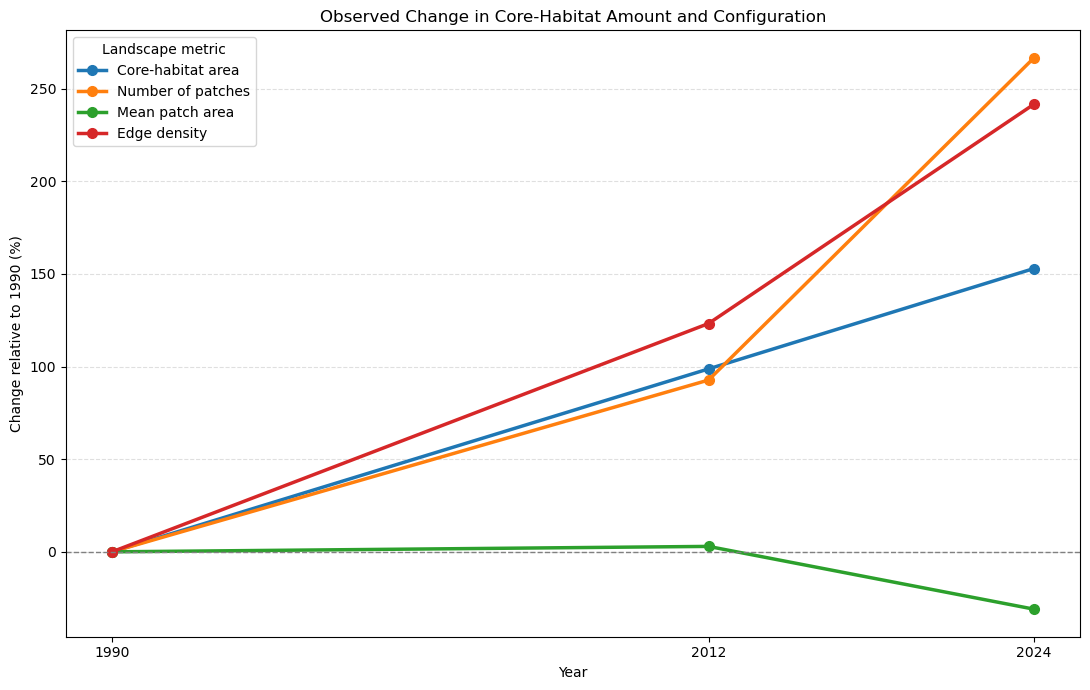

Figure saved:
C:\Users\smit1\BlackGrouse_2030\outputs\figures\observed_core_habitat_amount_and_fragmentation.png


In [4]:
observed_plot_data = observed_metrics[
    [
        "year",
        "core_habitat_area_km2",
        "number_of_patches",
        "mean_patch_area_km2",
        "edge_density_m_per_ha",
    ]
].copy()


METRIC_LABELS = {
    "core_habitat_area_km2": "Core-habitat area",
    "number_of_patches": "Number of patches",
    "mean_patch_area_km2": "Mean patch area",
    "edge_density_m_per_ha": "Edge density",
}


# Express each metric as percentage change relative to 1990
for metric_name in METRIC_LABELS:

    baseline_value = observed_plot_data.loc[
        observed_plot_data["year"] == 1990,
        metric_name,
    ].iloc[0]

    observed_plot_data[
        f"{metric_name}_change"
    ] = (
        (
            observed_plot_data[metric_name]
            - baseline_value
        )
        / baseline_value
        * 100
    )


fig, ax = plt.subplots(figsize=(11, 7))


for metric_name, metric_label in METRIC_LABELS.items():

    ax.plot(
        observed_plot_data["year"],
        observed_plot_data[
            f"{metric_name}_change"
        ],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=metric_label,
    )


ax.axhline(
    0,
    color="grey",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Observed Change in Core-Habitat Amount and Configuration"
)

ax.set_xlabel("Year")
ax.set_ylabel("Change relative to 1990 (%)")

ax.set_xticks(
    [1990, 2012, 2024]
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

ax.legend(
    title="Landscape metric",
    loc="upper left",
)

plt.tight_layout()


OBSERVED_CHANGE_FIGURE_PATH = (
    FIGURES_DIR
    / "observed_core_habitat_amount_and_fragmentation.png"
)

plt.savefig(
    OBSERVED_CHANGE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Figure saved:")
print(OBSERVED_CHANGE_FIGURE_PATH)

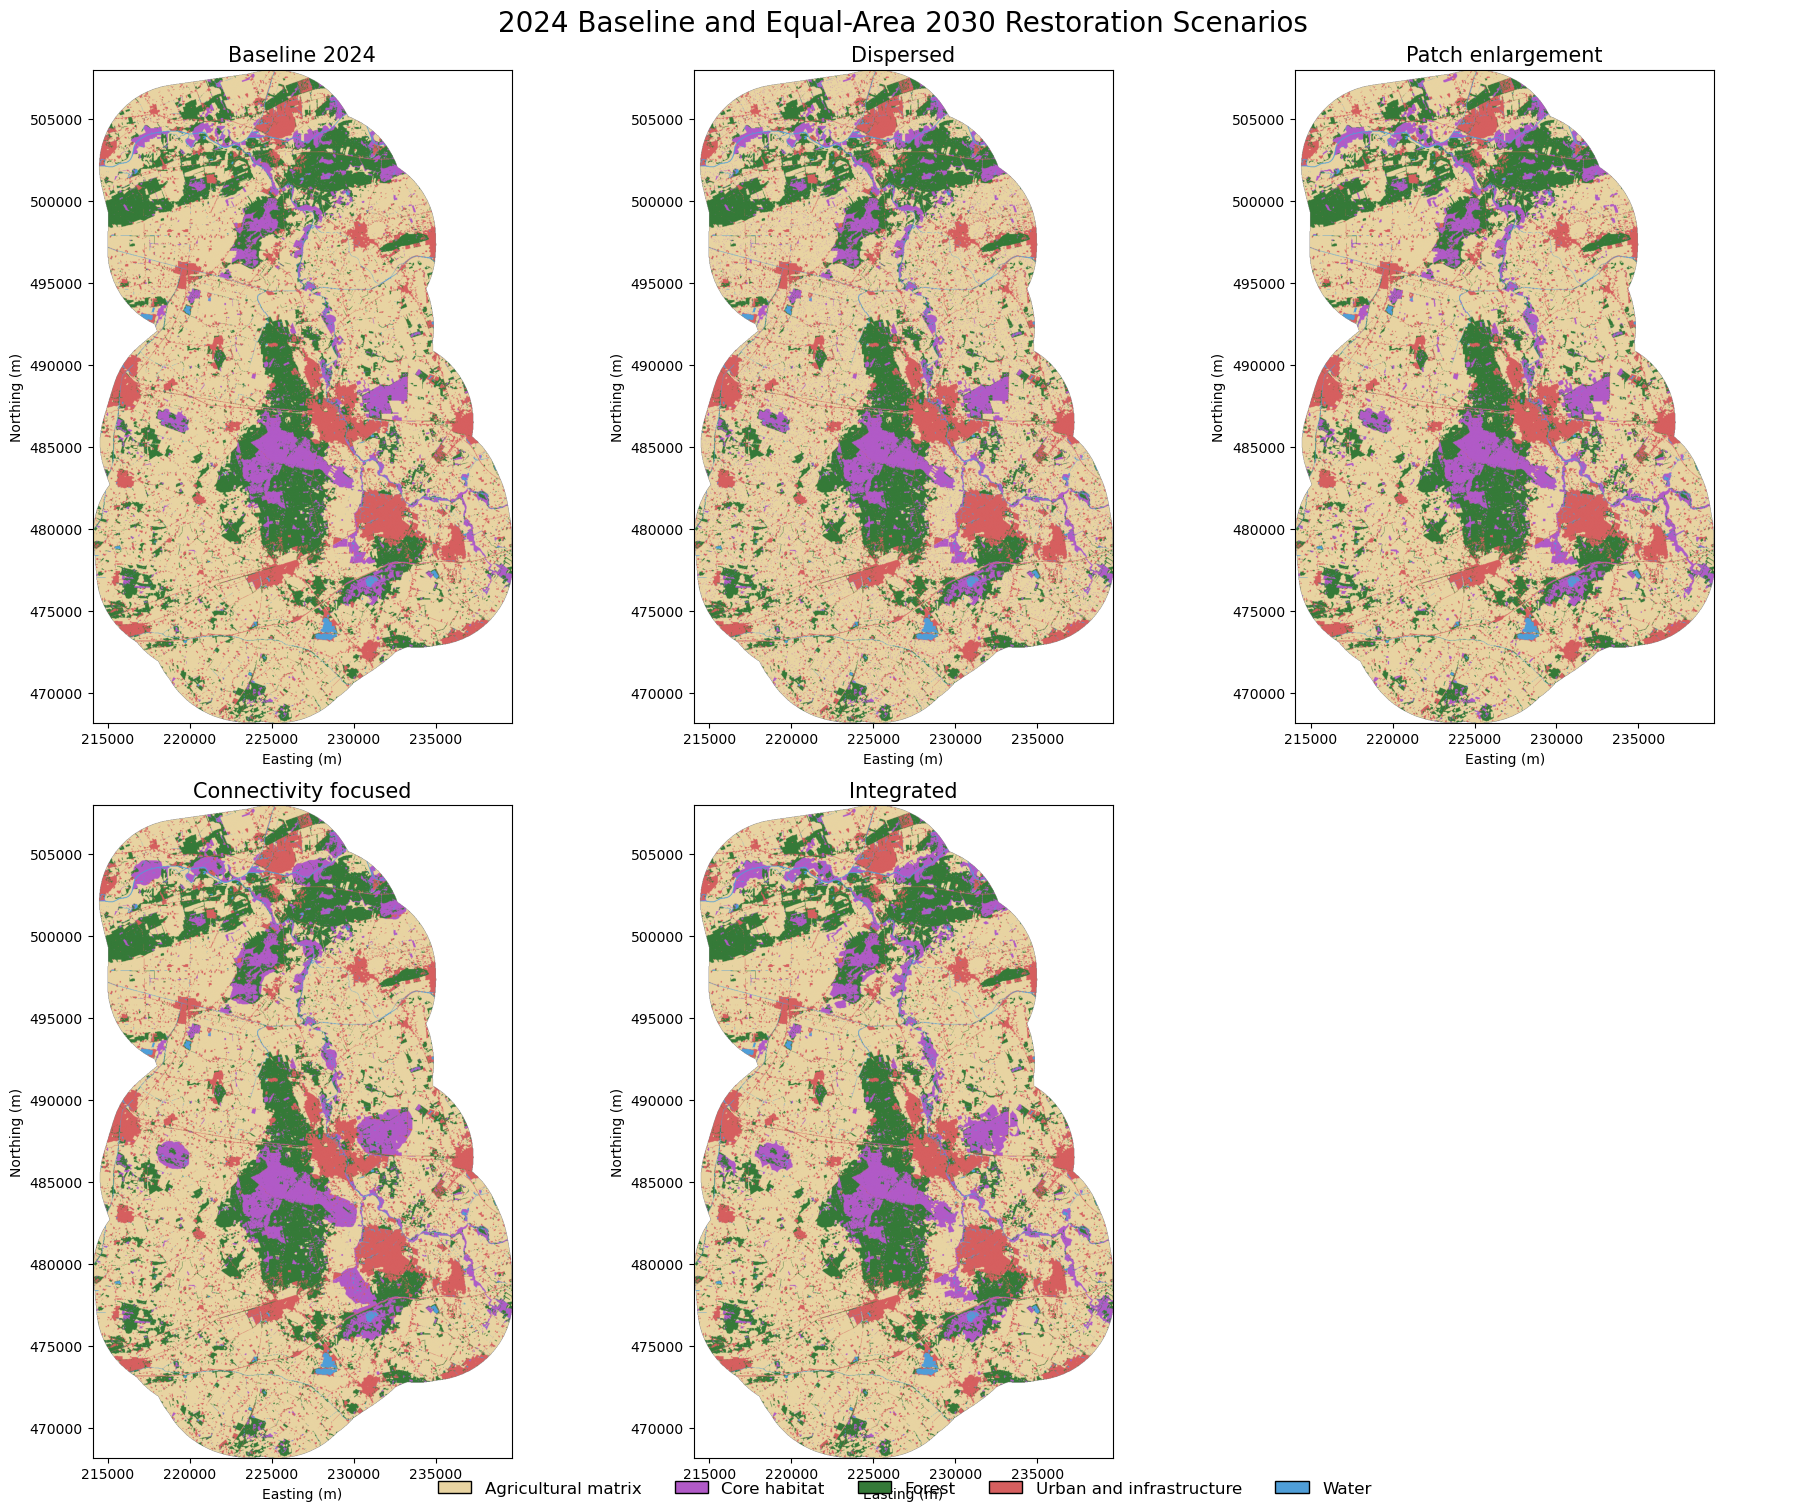

Figure saved:
C:\Users\smit1\BlackGrouse_2030\outputs\figures\baseline_2024_and_2030_restoration_scenarios.png


In [5]:
LANDUSE_COLOURS = {
    1: "#e8d4a2",
    2: "#b15ac7",
    3: "#357a38",
    4: "#d65f5f",
    5: "#4f9ed8",
}

LANDUSE_LABELS = {
    1: "Agricultural matrix",
    2: "Core habitat",
    3: "Forest",
    4: "Urban and infrastructure",
    5: "Water",
}


landuse_colormap = ListedColormap(
    [
        LANDUSE_COLOURS[class_value]
        for class_value in range(1, 6)
    ]
)

landuse_norm = BoundaryNorm(
    boundaries=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    ncolors=landuse_colormap.N,
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 15),
    constrained_layout=True,
)

axes = axes.flatten()


for axis, (scenario_label, raster_path) in zip(
    axes,
    SCENARIO_RASTERS.items(),
):

    with rasterio.open(raster_path) as src:

        raster_data = src.read(1)

        raster_extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

    masked_raster = np.ma.masked_where(
        raster_data == 0,
        raster_data,
    )

    axis.imshow(
        masked_raster,
        cmap=landuse_colormap,
        norm=landuse_norm,
        extent=raster_extent,
        origin="upper",
    )

    axis.set_title(
        scenario_label,
        fontsize=15,
    )

    axis.set_xlabel("Easting (m)")
    axis.set_ylabel("Northing (m)")
    axis.set_aspect("equal")


# Hide the unused sixth panel
axes[-1].axis("off")


legend_items = [
    Patch(
        facecolor=LANDUSE_COLOURS[class_value],
        edgecolor="black",
        label=LANDUSE_LABELS[class_value],
    )
    for class_value in range(1, 6)
]


fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=12,
)

fig.suptitle(
    "2024 Baseline and Equal-Area 2030 Restoration Scenarios",
    fontsize=20,
)


SCENARIO_MAP_FIGURE_PATH = (
    FIGURES_DIR
    / "baseline_2024_and_2030_restoration_scenarios.png"
)

plt.savefig(
    SCENARIO_MAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Figure saved:")
print(SCENARIO_MAP_FIGURE_PATH)

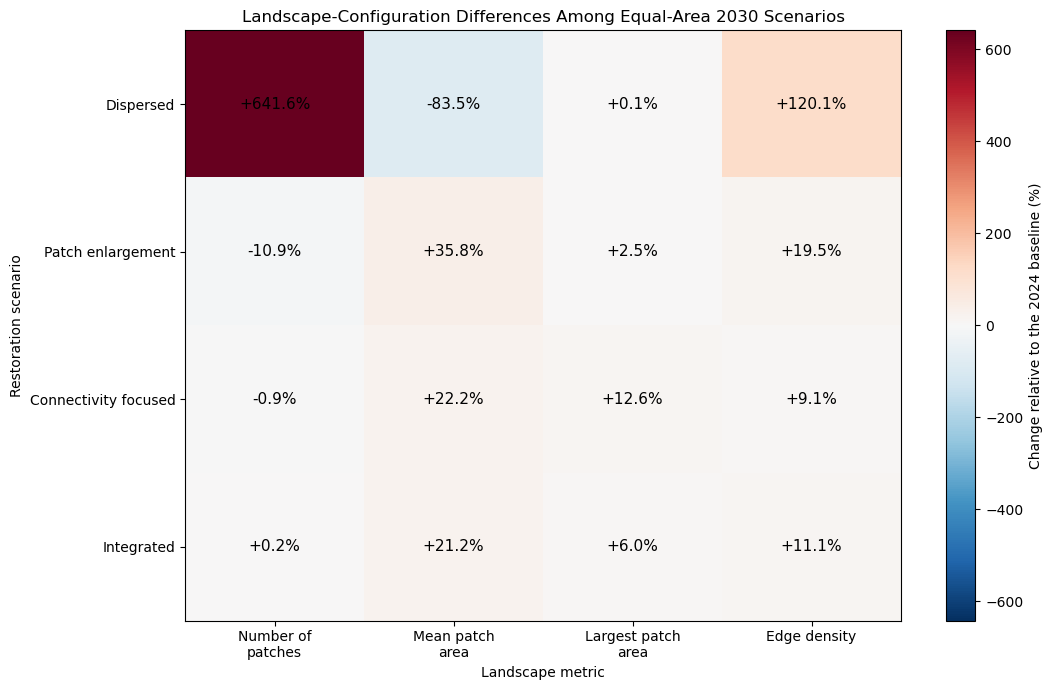

Figure saved:
C:\Users\smit1\BlackGrouse_2030\outputs\figures\2030_scenario_landscape_configuration_comparison.png


In [6]:
configuration_metrics = [
    "number_of_patches",
    "mean_patch_area_km2",
    "largest_patch_area_km2",
    "edge_density_m_per_ha",
]

configuration_labels = [
    "Number of\npatches",
    "Mean patch\narea",
    "Largest patch\narea",
    "Edge density",
]

scenario_plot_data = (
    scenario_metrics[
        scenario_metrics["scenario"] != "baseline_2024"
    ]
    .set_index("scenario")
    .loc[
        [
            "dispersed",
            "patch_enlargement",
            "connectivity_focused",
            "integrated_low_matrix_pressure",
        ]
    ]
)

baseline_values = (
    scenario_metrics[
        scenario_metrics["scenario"] == "baseline_2024"
    ]
    .iloc[0]
)

percentage_changes = []

for scenario_name, scenario_row in scenario_plot_data.iterrows():

    scenario_changes = []

    for metric_name in configuration_metrics:

        baseline_value = float(
            baseline_values[metric_name]
        )

        scenario_value = float(
            scenario_row[metric_name]
        )

        percentage_change = (
            (
                scenario_value - baseline_value
            )
            / baseline_value
            * 100
        )

        scenario_changes.append(
            percentage_change
        )

    percentage_changes.append(
        scenario_changes
    )


percentage_changes = np.array(
    percentage_changes
)


scenario_labels = [
    "Dispersed",
    "Patch enlargement",
    "Connectivity focused",
    "Integrated",
]


maximum_absolute_change = np.nanmax(
    np.abs(percentage_changes)
)


fig, ax = plt.subplots(
    figsize=(11, 7)
)

image = ax.imshow(
    percentage_changes,
    cmap="RdBu_r",
    aspect="auto",
    vmin=-maximum_absolute_change,
    vmax=maximum_absolute_change,
)


ax.set_xticks(
    np.arange(
        len(configuration_labels)
    )
)

ax.set_xticklabels(
    configuration_labels
)

ax.set_yticks(
    np.arange(
        len(scenario_labels)
    )
)

ax.set_yticklabels(
    scenario_labels
)


for row_index in range(
    percentage_changes.shape[0]
):

    for column_index in range(
        percentage_changes.shape[1]
    ):

        value = percentage_changes[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:+.1f}%",
            ha="center",
            va="center",
            fontsize=11,
        )


colour_bar = fig.colorbar(
    image,
    ax=ax,
)

colour_bar.set_label(
    "Change relative to the 2024 baseline (%)"
)


ax.set_title(
    "Landscape-Configuration Differences Among Equal-Area 2030 Scenarios"
)

ax.set_xlabel(
    "Landscape metric"
)

ax.set_ylabel(
    "Restoration scenario"
)


plt.tight_layout()


CONFIGURATION_FIGURE_PATH = (
    FIGURES_DIR
    / "2030_scenario_landscape_configuration_comparison.png"
)

plt.savefig(
    CONFIGURATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Figure saved:")
print(CONFIGURATION_FIGURE_PATH)

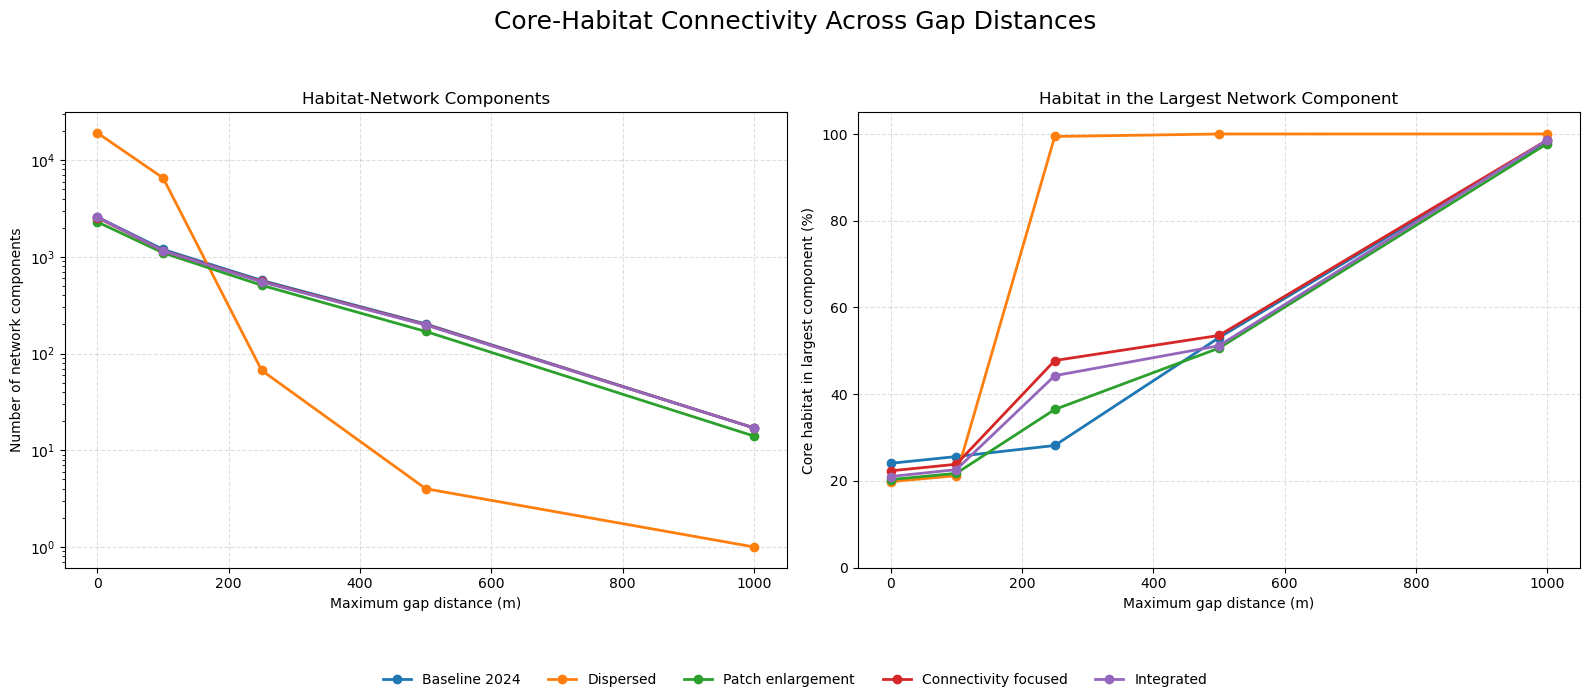

Figure saved:
C:\Users\smit1\BlackGrouse_2030\outputs\figures\2030_scenario_connectivity_comparison.png


In [7]:
connectivity_plot_data = connectivity_metrics.copy()

connectivity_plot_data["scenario_label"] = (
    connectivity_plot_data["scenario"]
    .map(SCENARIO_LABELS)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7),
)


for scenario_name in SCENARIO_ORDER:

    scenario_data = connectivity_plot_data[
        connectivity_plot_data["scenario"] == scenario_name
    ].sort_values("gap_distance_m")

    scenario_label = SCENARIO_LABELS[
        scenario_name
    ]

    axes[0].plot(
        scenario_data["gap_distance_m"],
        scenario_data["network_component_count"],
        marker="o",
        linewidth=2,
        label=scenario_label,
    )

    axes[1].plot(
        scenario_data["gap_distance_m"],
        scenario_data[
            "largest_component_habitat_percent"
        ],
        marker="o",
        linewidth=2,
        label=scenario_label,
    )


axes[0].set_title(
    "Habitat-Network Components"
)

axes[0].set_xlabel(
    "Maximum gap distance (m)"
)

axes[0].set_ylabel(
    "Number of network components"
)

axes[0].set_yscale("log")

axes[0].grid(
    linestyle="--",
    alpha=0.4,
)


axes[1].set_title(
    "Habitat in the Largest Network Component"
)

axes[1].set_xlabel(
    "Maximum gap distance (m)"
)

axes[1].set_ylabel(
    "Core habitat in largest component (%)"
)

axes[1].set_ylim(
    0,
    105,
)

axes[1].grid(
    linestyle="--",
    alpha=0.4,
)


handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=False,
)

fig.suptitle(
    "Core-Habitat Connectivity Across Gap Distances",
    fontsize=18,
)

plt.tight_layout(
    rect=[0, 0.10, 1, 0.94]
)


CONNECTIVITY_FIGURE_PATH = (
    FIGURES_DIR
    / "2030_scenario_connectivity_comparison.png"
)

plt.savefig(
    CONNECTIVITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Figure saved:")
print(CONNECTIVITY_FIGURE_PATH)